<a href="https://colab.research.google.com/github/dubeyananya3012-wq/aflpm/blob/main/AFLPM_Colab_fixed_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 AFLPM: Adaptive Federated Learning for Predictive Maintenance
### Google Colab Implementation

**Based on:** *"Federated Learning for Privacy-Preserving Predictive Maintenance in Industrial IoT Systems"*  
**Authors:** Aditi Kamath (16010423005) · Ananya Dubey (16010423011) · Hiranya Patil (16010423037)

---

### 📋 Quick Start
1. **Runtime → Change runtime type → T4 GPU** *(recommended)*
2. **Runtime → Run all** — cells execute top to bottom automatically
3. Results tables + 8 figures will appear inline

### 🗂️ What this notebook implements
| Component | Paper Section |
|-----------|--------------|
| CNN-LSTM-Attention local model | Table VI / Section XI |
| Reliability-scored device selection | Equation 8 / Algorithm 1 |
| Top-K gradient sparsification + error buffer | Contribution 2 |
| Non-IID data partitioning (Dirichlet α=0.5) | Section IX-B |
| AFLPM federated training loop | Algorithm 1 & 2 |
| CML / ELL / FedAvg baselines | Section X |
| NASA CMAPSS FD001 + CWRU Bearing datasets | Section IX-A |
| Full metrics + 8 visualisation figures | Sections XVII–XIX |


## Cell: Install dependencies

In [2]:
import glob, zipfile, os, urllib.request

DATA_URL = "https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip"
outer_zip = "/content/cmapss_outer.zip"

if not os.path.exists(outer_zip):
    print("Downloading CMAPSS dataset...")
    urllib.request.urlretrieve(DATA_URL, outer_zip)

with zipfile.ZipFile(outer_zip, 'r') as z:
    z.extractall("/content/CMAPSSData")

# The outer zip contains a nested CMAPSSData.zip - find and extract it too
inner_zips = glob.glob("/content/CMAPSSData/**/*.zip", recursive=True)
if inner_zips:
    with zipfile.ZipFile(inner_zips[0], 'r') as z:
        z.extractall("/content/CMAPSSData_final")
    print(f"Extracted inner zip: {inner_zips[0]}")
else:
    os.makedirs("/content/CMAPSSData_final", exist_ok=True)
    for f in glob.glob("/content/CMAPSSData/**/*FD001*", recursive=True):
        os.system(f'cp "{f}" /content/CMAPSSData_final/')
    print("No nested zip found - copied FD001 files directly")

print("\nFiles found:")
for f in sorted(glob.glob("/content/CMAPSSData_final/**/*FD001*", recursive=True)):
    print(" ", f)


Extracted inner zip: /content/CMAPSSData/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip

Files found:
  /content/CMAPSSData_final/RUL_FD001.txt
  /content/CMAPSSData_final/test_FD001.txt
  /content/CMAPSSData_final/train_FD001.txt


In [3]:
"""
!pip install flwr==1.6.0 torch torchvision imbalanced-learn mlflow seaborn -q
"""

'\n!pip install flwr==1.6.0 torch torchvision imbalanced-learn mlflow seaborn -q\n'

## Cell: Imports & reproducibility seed

In [4]:
import os, math, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Cell: Hyperparameters (match paper Table VIII exactly)

In [5]:
CFG = {
    # Federated
    "NUM_DEVICES"    : 10,       # N edge devices
    "ROUNDS"         : 50,       # R (reduced from 100 for Colab speed; set 100 for full run)
    "LOCAL_EPOCHS"   : 5,        # E
    "BATCH_SIZE"     : 32,       # B
    "LR"             : 1e-3,     # η (Adam)
    "TOP_K"          : 0.20,     # K₀ — fraction of gradients to transmit
    "R_THRESHOLD"    : 0.55,     # Reliability score cutoff
    "ALPHA_1"        : 0.3,      # weight: dataset size
    "ALPHA_2"        : 0.5,      # weight: validation accuracy
    "ALPHA_3"        : 0.2,      # weight: network latency proxy
    "MIN_DEVICES"    : 4,        # min active devices per round
    # Model / data
    "WINDOW"         : 30,       # sliding window W
    "STRIDE"         : 1,
    "FAULT_THRESH"   : 0.7,      # δ threshold for fault alert
    "DIRICHLET_ALPHA": 0.5,      # non-IID concentration
    # Training split
    "TRAIN_RATIO"    : 0.70,
    "VAL_RATIO"      : 0.10,
    "TEST_RATIO"     : 0.20,
    # Convergence early stop
    "CONV_DELTA"     : 0.001,
    "CONV_PATIENCE"  : 5,
}
print("Hyperparameters loaded")

Hyperparameters loaded


## Cell: Dataset loader (NASA CMAPSS FD001 + CWRU Bearing)

In [6]:
def load_cmapss_fd001():
    """
    Loads NASA CMAPSS FD001 from the locally extracted files.
    Keeps the engine "id" column (needed downstream to split
    train/test by engine, not by row - fixes leakage C1/C2).
    """
    import glob

    cols = (["id","cycle"] +
            [f"op{i}" for i in range(1,4)] +
            [f"s{i}" for i in range(1,22)])

    matches = glob.glob("/content/CMAPSSData_final/**/train_FD001.txt", recursive=True)

    if matches:
        train_path = matches[0]
        df = pd.read_csv(train_path, sep=r"\s+", header=None, names=cols, engine="python")
        print(f"Loaded real CMAPSS FD001 data from: {train_path}  ({len(df)} rows)")
    else:
        print("WARNING: train_FD001.txt not found under /content/CMAPSSData_final - "
              "generating synthetic data. Check that you uploaded and unzipped the CMAPSS zip.")
        df = _synthetic_cmapss(cols)

    df.ffill(inplace=True)

    max_cycle = df.groupby("id")["cycle"].max().rename("max_cycle")
    df = df.join(max_cycle, on="id")
    df["RUL"] = df["max_cycle"] - df["cycle"]
    df["label"] = (df["RUL"] <= 30).astype(int)

    # Drop everything except id (kept for leakage-safe splitting), the
    # feature columns, and the label.
    drop_cols = ["cycle","op3","s1","s5","s6","s10","s16","s18","s19",
                 "max_cycle","RUL"]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df.drop(columns=drop_cols, inplace=True)

    return df

def _synthetic_cmapss(cols):
    """Synthetic stand-in when local files are unavailable."""
    n_engines, n_cycles = 100, 200
    rows = []
    for eid in range(1, n_engines+1):
        for cyc in range(1, n_cycles+1):
            row = [eid, cyc] + list(np.random.randn(3)) + list(np.random.randn(21))
            rows.append(row)
    return pd.DataFrame(rows, columns=cols)


def load_cwru_bearing():
    """
    Downloads and loads the REAL Case Western Reserve University (CWRU)
    Bearing Data Center dataset (fixes C4 - previously this generated
    fake Gaussian clusters instead of real vibration data).

    Uses the 0 HP / 1797 RPM, 0.007" fault-diameter drive-end files:
      Normal      -> 97.mat
      Inner Race  -> 105.mat
      Ball        -> 118.mat
      Outer Race  -> 130.mat  (centered @6:00)

    Each file's drive-end (DE) vibration signal is cut into overlapping
    windows; 8 time-domain + 8 FFT-band-energy features are extracted
    per window (16 features total, matching the original feature count).
    Binary label: 0 = normal, 1 = any fault.
    """
    import scipy.io as sio
    import urllib.request, os

    FILES = {
        "normal":     "97.mat",
        "inner_race": "105.mat",
        "ball":       "118.mat",
        "outer_race": "130.mat",
    }
    BASE_URL  = "https://engineering.case.edu/sites/default/files/"
    CACHE_DIR = "/content/cwru_raw"
    os.makedirs(CACHE_DIR, exist_ok=True)

    WINDOW, STRIDE = 1024, 64
    MAX_PER_CLASS  = 4000

    def download(fname):
        path = os.path.join(CACHE_DIR, fname)
        if not os.path.exists(path):
            urllib.request.urlretrieve(BASE_URL + fname, path)
        return path

    def get_de_signal(matpath):
        mat = sio.loadmat(matpath)
        de_keys = [k for k in mat.keys() if k.endswith("DE_time")]
        if not de_keys:
            raise ValueError(f"No DE_time signal found in {matpath}: {list(mat.keys())}")
        return mat[de_keys[0]].squeeze().astype(np.float64)

    def extract_features(sig):
        mean, std = sig.mean(), sig.std() + 1e-8
        rms  = np.sqrt(np.mean(sig**2))
        peak = np.max(np.abs(sig))
        ptp  = sig.max() - sig.min()
        crest = peak / (rms + 1e-8)
        skew = ((sig - mean)**3).mean() / (std**3)
        kurt = ((sig - mean)**4).mean() / (std**4)
        td = [mean, std, rms, peak, ptp, crest, skew, kurt]

        fft_mag = np.abs(np.fft.rfft(sig))
        bands = np.array_split(fft_mag, 8)
        fft_feats = [b.mean() for b in bands]
        return td + fft_feats

    rows = []
    print("Downloading real CWRU bearing data from engineering.case.edu ...")
    for cls_name, fname in FILES.items():
        path = download(fname)
        sig = get_de_signal(path)
        n_windows = min(MAX_PER_CLASS, max(0, (len(sig) - WINDOW) // STRIDE + 1))
        label = 0 if cls_name == "normal" else 1
        for i in range(n_windows):
            start = i * STRIDE
            feats = extract_features(sig[start:start + WINDOW])
            rows.append(feats + [label])
        print(f"  {cls_name:12s}: {n_windows} windows from {fname}")

    feat_cols = [f"td_{i}" for i in range(8)] + [f"fft_{i}" for i in range(8)]
    df = pd.DataFrame(rows, columns=feat_cols + ["label"])
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f"Loaded real CWRU data: {len(df)} total windows, "
          f"fault ratio = {df['label'].mean():.2%}")
    return df

print("Dataset loaders defined")


Dataset loaders defined


## Cell: Preprocessing pipeline

In [7]:
def _windowize_group(X_raw, y_raw, window, stride):
    X_win, y_win = [], []
    for i in range(0, len(X_raw) - window + 1, stride):
        X_win.append(X_raw[i:i+window])
        y_win.append(y_raw[i+window-1])
    return X_win, y_win

def windowize(df, feat_cols, label_col, window, stride, id_col=None):
    """
    Sliding-window generator. If id_col is present, windows are built
    PER GROUP (e.g. per engine) so a window never spans two different
    engines. This is applied separately to already-split train/test
    dataframes, so windows also never span the train/test boundary
    (fixes C2).
    """
    X_win, y_win = [], []
    if id_col and id_col in df.columns:
        for _, g in df.groupby(id_col):
            Xg, yg = g[feat_cols].values, g[label_col].values
            xw, yw = _windowize_group(Xg, yg, window, stride)
            X_win.extend(xw); y_win.extend(yw)
    else:
        Xg, yg = df[feat_cols].values, df[label_col].values
        xw, yw = _windowize_group(Xg, yg, window, stride)
        X_win.extend(xw); y_win.extend(yw)
    return (np.array(X_win, dtype=np.float32),
            np.array(y_win, dtype=np.float32))


def prepare_dataset(df, window=CFG["WINDOW"], stride=CFG["STRIDE"],
                     test_ratio=CFG["TEST_RATIO"], id_col="id", label_col="label"):
    """
    Leakage-safe pipeline (fixes C1 + C2 from the review):
      1. Split into train/test BEFORE any windowing, scaling, or SMOTE.
         If an id_col exists (e.g. CMAPSS engine id) the split is done
         by whole id/engine, never by individual row - so a window can
         never straddle the train/test boundary.
      2. MinMax scaler is fit on the TRAIN split only, then applied to
         both splits (prevents feature-scaling leakage too).
      3. Windowing is done separately per split (see windowize above).
      4. SMOTE is applied to the TRAIN windows only, never to test.
    """
    feat_cols = [c for c in df.columns if c not in (label_col, id_col)]

    if id_col in df.columns:
        ids = df[id_col].unique()
        id_has_fault = df.groupby(id_col)[label_col].max()
        train_ids, test_ids = train_test_split(
            ids, test_size=test_ratio, random_state=SEED,
            stratify=id_has_fault.loc[ids].values)
        train_df = df[df[id_col].isin(train_ids)].copy()
        test_df  = df[df[id_col].isin(test_ids)].copy()
    else:
        train_df, test_df = train_test_split(
            df, test_size=test_ratio, random_state=SEED, stratify=df[label_col])
        train_df, test_df = train_df.copy(), test_df.copy()

    scaler = MinMaxScaler()
    train_df[feat_cols] = scaler.fit_transform(train_df[feat_cols])
    test_df[feat_cols]  = scaler.transform(test_df[feat_cols])

    X_train, y_train = windowize(train_df, feat_cols, label_col, window, stride, id_col)
    X_test,  y_test  = windowize(test_df,  feat_cols, label_col, window, stride, id_col)

    if y_train.sum() > 0:
        N, W, F = X_train.shape
        X_flat = X_train.reshape(N, W*F)
        try:
            sm = SMOTE(random_state=SEED, k_neighbors=min(5, int(y_train.sum())-1))
            X_flat, y_train = sm.fit_resample(X_flat, y_train)
            X_train = X_flat.reshape(-1, W, F).astype(np.float32)
            y_train = y_train.astype(np.float32)
        except Exception:
            pass   # skip SMOTE if too few minority samples

    return X_train, y_train, X_test, y_test


def non_iid_split(X, y, n_devices, alpha=CFG["DIRICHLET_ALPHA"]):
    """
    Partition (X,y) across n_devices using Dirichlet distribution
    to simulate non-IID data (Section IX-B).
    """
    classes = np.unique(y).astype(int)
    class_idx = {c: np.where(y == c)[0] for c in classes}
    device_idx = defaultdict(list)

    for c in classes:
        idx = class_idx[c]
        np.random.shuffle(idx)
        proportions = np.random.dirichlet([alpha]*n_devices)
        splits = (proportions * len(idx)).astype(int)
        splits[-1] = len(idx) - splits[:-1].sum()   # ensure sum matches
        ptr = 0
        for d in range(n_devices):
            device_idx[d].extend(idx[ptr:ptr+splits[d]].tolist())
            ptr += splits[d]

    partitions = []
    for d in range(n_devices):
        idx = np.array(device_idx[d])
        if len(idx) == 0:
            idx = np.random.choice(len(X), 20)   # ensure non-empty
        partitions.append((X[idx], y[idx]))
    return partitions

def split_device_data(X, y, train_r=CFG["TRAIN_RATIO"],
                      val_r=CFG["VAL_RATIO"]):
    """Train / val / test split per device."""
    n = len(X)
    train_end = int(n * train_r)
    val_end   = int(n * (train_r + val_r))
    return (X[:train_end], y[:train_end],
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:])

print("Preprocessing utilities defined")


Preprocessing utilities defined


## Cell: CNN-LSTM-Attention model (Table VI)

In [8]:
class CNNLSTMAttention(nn.Module):
    """
    Local model architecture (Section XI, Table VI):
      Conv1D(64) → Conv1D(128) → LSTM(128,2) → MultiheadAttn(4) →
      GlobalAvgPool → Dense(64) → Sigmoid
    """
    def __init__(self, n_features: int, window: int = CFG["WINDOW"]):
        super().__init__()
        # ── CNN block ──────────────────────────────────────────────────────
        self.conv1 = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        # ── LSTM block ─────────────────────────────────────────────────────
        self.lstm = nn.LSTM(128, 128, num_layers=2,
                            batch_first=True, dropout=0.3)
        # ── Self-Attention block ───────────────────────────────────────────
        self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=4,
                                               batch_first=True, dropout=0.1)
        # ── Classifier head ───────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, W, F)
        x = x.permute(0, 2, 1)          # → (B, F, W) for Conv1d
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.permute(0, 2, 1)          # → (B, T', 128) for LSTM
        x, _ = self.lstm(x)
        x, _ = self.attention(x, x, x)  # self-attention
        x = x.mean(dim=1)               # global average pool over time
        return self.classifier(x).squeeze(-1)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Quick sanity check
_dummy_model = CNNLSTMAttention(n_features=14, window=30).to(DEVICE)
_dummy_in    = torch.randn(4, 30, 14).to(DEVICE)
_dummy_out   = _dummy_model(_dummy_in)
print(f"Model output shape: {_dummy_out.shape}  "
      f"| Params: {count_parameters(_dummy_model):,}")

Model output shape: torch.Size([4])  | Params: 366,017


## Cell: Top-K gradient sparsification with error accumulation (Section XI)

In [9]:
class TopKSparsifier:
    """
    Contribution 2: Top-K gradient sparsification.
    Keeps the K₀ largest-magnitude gradient elements per round,
    accumulates the dropped residuals in an error buffer.
    """
    def __init__(self, k0: float = CFG["TOP_K"]):
        self.k0     = k0
        self.buffer = {}   # error accumulation buffer e_i

    def compress(self, delta_w: dict) -> dict:
        """Apply top-K sparsification + error buffering."""
        sparse = {}
        for name, grad in delta_w.items():
            # Add accumulated error
            prev_err = self.buffer.get(name, torch.zeros_like(grad))
            corrected = grad + prev_err

            # Flatten, find top-K elements
            flat    = corrected.view(-1)
            k       = max(1, int(flat.numel() * self.k0))
            _, idx  = torch.topk(flat.abs(), k)

            # Build sparse tensor
            sparse_flat         = torch.zeros_like(flat)
            sparse_flat[idx]    = flat[idx]
            sparse[name]        = sparse_flat.view_as(grad)

            # Update error buffer
            self.buffer[name]   = corrected - sparse[name]

        return sparse

    def communication_mb(self, model: nn.Module) -> float:
        """Estimate MB transmitted (top-K fraction of full gradient)."""
        total_params = sum(p.numel() for p in model.parameters())
        return total_params * self.k0 * 4 / (1024**2)  # float32 = 4 bytes

print("TopK Sparsifier defined")

TopK Sparsifier defined


## Cell: Reliability-scored device selection (Equation 8)

In [10]:
class ReliabilityScorer:
    """
    Contribution 1: Assigns each device a reliability score R_i.
    R_i = α₁*(|D_i|/|D_max|) + α₂*A_i + α₃*(1 - λ_i/λ_max)
    """
    def __init__(self, a1=CFG["ALPHA_1"], a2=CFG["ALPHA_2"],
                 a3=CFG["ALPHA_3"], threshold=CFG["R_THRESHOLD"]):
        self.a1 = a1; self.a2 = a2; self.a3 = a3
        self.threshold = threshold

    def score(self, dataset_sizes, val_accs, latencies):
        d_max  = max(dataset_sizes) if max(dataset_sizes) > 0 else 1
        l_max  = max(latencies)     if max(latencies) > 0     else 1
        scores = []
        for ds, acc, lat in zip(dataset_sizes, val_accs, latencies):
            r = (self.a1 * ds / d_max +
                 self.a2 * acc +
                 self.a3 * (1 - lat / l_max))
            scores.append(round(r, 4))
        return scores

    def select(self, scores, min_devices=CFG["MIN_DEVICES"]):
        selected = [i for i, s in enumerate(scores) if s >= self.threshold]
        if len(selected) < min_devices:
            selected = sorted(range(len(scores)),
                              key=lambda i: scores[i], reverse=True)[:min_devices]
        return selected

print("Reliability Scorer defined")

Reliability Scorer defined


## Cell: Local training (Algorithm 2 – client side)

In [11]:
def local_train(model, X_train, y_train, X_val, y_val,
                epochs=CFG["LOCAL_EPOCHS"], lr=CFG["LR"],
                batch_size=CFG["BATCH_SIZE"]):
    """
    Train model locally for E epochs; return updated model and val accuracy.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    ds  = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        for Xb, yb in dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    # Validation accuracy
    model.eval()
    with torch.no_grad():
        Xv = torch.FloatTensor(X_val).to(DEVICE)
        yv = torch.FloatTensor(y_val).to(DEVICE)
        pv = model(Xv)
        val_acc = ((pv >= 0.5).float() == yv).float().mean().item()

    return model, val_acc

print("Local training function defined")

Local training function defined


## Cell: FedAvg aggregation (Equation 3 / Algorithm 1)

In [12]:
def fedavg_aggregate(global_model, sparse_updates, dataset_sizes):
    """
    Sparse weighted FedAvg aggregation (Section XIII, Step 10):
    G^(r+1) = G^(r) + Σ (|D_i|/|D_K|) * ΔW_sparse_i
    """
    total = sum(dataset_sizes)
    global_dict = global_model.state_dict()

    for name in global_dict:
        weighted_sum = torch.zeros_like(global_dict[name], dtype=torch.float32)
        for upd, ds in zip(sparse_updates, dataset_sizes):
            if name in upd:
                weighted_sum += (ds / total) * upd[name].to(DEVICE)
        global_dict[name] = global_dict[name].float() + weighted_sum

    global_model.load_state_dict(global_dict)
    return global_model

print("Aggregation function defined")

Aggregation function defined


## Cell: Evaluation utilities

In [13]:
def evaluate(model, X_test, y_test, threshold=0.5):
    model.eval()
    with torch.no_grad():
        Xt = torch.FloatTensor(X_test).to(DEVICE)
        probs = model(Xt).cpu().numpy()
    preds = (probs >= threshold).astype(int)
    y_int = y_test.astype(int)
    return {
        "accuracy"  : accuracy_score(y_int, preds),
        "precision" : precision_score(y_int, preds, zero_division=0),
        "recall"    : recall_score(y_int, preds, zero_division=0),
        "f1"        : f1_score(y_int, preds, zero_division=0),
        "auc"       : roc_auc_score(y_int, probs) if len(np.unique(y_int)) > 1 else 0.5,
        "probs"     : probs,
    }

def measure_latency(model, X_sample, n_runs=100):
    """Average inference latency in ms (Section XVII)."""
    model.eval()
    Xs = torch.FloatTensor(X_sample[:1]).to(DEVICE)   # single window
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(Xs)
            times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times[10:])   # discard first 10 warm-up runs

print("Evaluation utilities defined")

Evaluation utilities defined


## Cell: Main AFLPM federated training loop (Algorithm 1)

In [14]:
def run_aflpm(partitions, X_global_test, y_global_test,
              n_features, dataset_name="Dataset"):
    """
    Full AFLPM training loop.
    Returns: global model, per-round metrics dict.
    """
    print(f"\n{'='*60}")
    print(f"  AFLPM Training — {dataset_name}")
    print(f"{'='*60}")

    N  = CFG["NUM_DEVICES"]
    scorer    = ReliabilityScorer()
    sparsifiers = [TopKSparsifier(CFG["TOP_K"]) for _ in range(N)]

    # Simulate per-device latency (ms) once — fixed proxy for hardware speed
    device_latencies = np.random.uniform(10, 150, N)

    # Initialise global model (Xavier init is PyTorch default for Linear)
    global_model = CNNLSTMAttention(n_features, CFG["WINDOW"]).to(DEVICE)

    # Prepare per-device splits
    device_data = []
    for X_d, y_d in partitions:
        if len(X_d) < 10:
            X_d = np.tile(X_d, (10, 1, 1))[:10]
            y_d = np.tile(y_d, 10)[:10]
        Xtr, ytr, Xvl, yvl, Xte, yte = split_device_data(X_d, y_d)
        device_data.append((Xtr, ytr, Xvl, yvl, Xte, yte))

    dataset_sizes = [len(d[0]) for d in device_data]

    metrics = {
        "round": [], "val_acc_global": [], "ccr_mb": [],
        "n_selected": [], "reliability_scores": []
    }
    best_acc    = 0.0
    patience_ct = 0

    # Fix C3: track each device's most recent REAL validation accuracy
    # across rounds (paper Eq. 8 requires this for the alpha_2 * A_i term).
    # Starts at 0.5 (no information yet) and is updated with the true
    # val_acc returned by local_train() every time a device is selected.
    prev_val_acc = {i: 0.5 for i in range(N)}

    for r in range(1, CFG["ROUNDS"] + 1):
        # ── Step 4: compute reliability scores ───────────────────────────
        # Fix C3: use each device's real validation accuracy from the
        # last round it participated in (was hard-coded to 0.5 before).
        val_accs = [prev_val_acc[i] for i in range(N)]
        scores = scorer.score(dataset_sizes, val_accs, device_latencies.tolist())

        # ── Step 5: select active devices ────────────────────────────────
        selected = scorer.select(scores)

        # ── Steps 6-9: local training + sparsification ───────────────────
        sparse_updates  = []
        sel_sizes       = []
        sel_val_accs    = []
        round_ccr       = 0.0

        global_state = copy.deepcopy(global_model.state_dict())

        for i in selected:
            Xtr, ytr, Xvl, yvl, _, _ = device_data[i]

            # Clone global model to local device
            local_model = CNNLSTMAttention(n_features, CFG["WINDOW"]).to(DEVICE)
            local_model.load_state_dict(copy.deepcopy(global_state))

            # Local training (E epochs)
            local_model, val_acc = local_train(local_model, Xtr, ytr, Xvl, yvl)
            sel_val_accs.append(val_acc)
            prev_val_acc[i] = val_acc   # Fix C3: persist real accuracy for next round

            # Compute gradient delta: ΔW = W_local - G^(r)
            local_state = local_model.state_dict()
            delta = {k: (local_state[k].float() - global_state[k].float())
                     for k in global_state}

            # Top-K sparsification with error accumulation
            sparse = sparsifiers[i].compress(delta)
            sparse_updates.append(sparse)
            sel_sizes.append(dataset_sizes[i])
            round_ccr += sparsifiers[i].communication_mb(local_model)

        # ── Step 10: aggregate ───────────────────────────────────────────
        global_model = fedavg_aggregate(global_model, sparse_updates, sel_sizes)

        # ── Step 11: evaluate on global test set ─────────────────────────
        res = evaluate(global_model, X_global_test, y_global_test)
        global_acc = res["accuracy"]

        metrics["round"].append(r)
        metrics["val_acc_global"].append(global_acc)
        metrics["ccr_mb"].append(round_ccr)
        metrics["n_selected"].append(len(selected))
        metrics["reliability_scores"].append(scores)

        if r % 10 == 0 or r == 1:
            print(f"  Round {r:3d} | Acc={global_acc:.4f} | "
                  f"CCR={round_ccr:.2f} MB | Selected={len(selected)}")

        # ── Early stop check ─────────────────────────────────────────────
        if global_acc - best_acc < CFG["CONV_DELTA"]:
            patience_ct += 1
        else:
            best_acc = global_acc
            patience_ct = 0
        if patience_ct >= CFG["CONV_PATIENCE"]:
            print(f"\n  Early stop at round {r} (Δacc < {CFG['CONV_DELTA']} "
                  f"for {CFG['CONV_PATIENCE']} rounds)")
            break

    return global_model, metrics

print("AFLPM training loop defined")

AFLPM training loop defined


## Cell: Baseline methods (CML, ELL, FedAvg)

In [15]:
def run_cml(partitions, X_global_test, y_global_test, n_features):
    """Centralized ML: pool all device data and train one model."""
    print("\n── CML (Centralized) training ──")
    X_all = np.concatenate([p[0] for p in partitions])
    y_all = np.concatenate([p[1] for p in partitions])

    model = CNNLSTMAttention(n_features, CFG["WINDOW"]).to(DEVICE)
    t0 = time.time()
    model, _ = local_train(model, X_all, y_all, X_global_test, y_global_test,
                           epochs=CFG["LOCAL_EPOCHS"]*5)
    latency = measure_latency(model, X_global_test)
    ccr = (X_all.nbytes) / (1024**2)   # raw data MB (simulated)
    res = evaluate(model, X_global_test, y_global_test)
    res.update({"latency_ms": latency, "ccr_mb": ccr, "conv_rounds": None})
    return res

def run_ell(partitions, X_global_test, y_global_test, n_features):
    """Edge-only: each device trains locally, pick best by val acc."""
    print("\n── ELL (Edge-Only) training ──")
    best_model, best_acc = None, -1
    for i, (Xtr, ytr, Xvl, yvl, _, _) in enumerate(
            [split_device_data(X, y) for X, y in partitions]):
        model = CNNLSTMAttention(n_features, CFG["WINDOW"]).to(DEVICE)
        model, va = local_train(model, Xtr, ytr, Xvl, yvl,
                                epochs=CFG["LOCAL_EPOCHS"]*3)
        if va > best_acc:
            best_acc   = va
            best_model = copy.deepcopy(model)
    latency = measure_latency(best_model, X_global_test)
    res = evaluate(best_model, X_global_test, y_global_test)
    res.update({"latency_ms": latency, "ccr_mb": 0.0, "conv_rounds": None})
    return res

def run_fedavg_std(partitions, X_global_test, y_global_test, n_features):
    """Standard FedAvg — no sparsification, no reliability scoring."""
    print("\n── Standard FedAvg training ──")
    global_model = CNNLSTMAttention(n_features, CFG["WINDOW"]).to(DEVICE)
    device_data  = [split_device_data(X, y) for X, y in partitions]
    dataset_sizes = [len(d[0]) for d in device_data]
    full_model_mb = (sum(p.numel() for p in global_model.parameters()) * 4
                     / (1024**2))

    best_acc  = 0; patience = 0; conv_round = CFG["ROUNDS"]
    round_metrics = []
    global_state = copy.deepcopy(global_model.state_dict())

    for r in range(1, CFG["ROUNDS"]+1):
        sel = list(range(CFG["NUM_DEVICES"]))   # all devices, no scoring
        updates, sizes = [], []

        for i in sel:
            Xtr, ytr, Xvl, yvl, _, _ = device_data[i]
            lm = CNNLSTMAttention(n_features, CFG["WINDOW"]).to(DEVICE)
            lm.load_state_dict(copy.deepcopy(global_state))
            lm, _ = local_train(lm, Xtr, ytr, Xvl, yvl)
            ls = lm.state_dict()
            # Full delta (no compression)
            delta = {k: ls[k].float() - global_state[k].float() for k in global_state}
            updates.append(delta)
            sizes.append(dataset_sizes[i])

        global_model = fedavg_aggregate(global_model, updates, sizes)
        global_state = global_model.state_dict()
        res = evaluate(global_model, X_global_test, y_global_test)
        round_metrics.append(res["accuracy"])

        if res["accuracy"] - best_acc < CFG["CONV_DELTA"]:
            patience += 1
        else:
            best_acc = res["accuracy"]; patience = 0
        if patience >= CFG["CONV_PATIENCE"]:
            conv_round = r; break

        if r % 10 == 0 or r == 1:
            print(f"  Round {r:3d} | Acc={res['accuracy']:.4f}")

    latency = measure_latency(global_model, X_global_test)
    res = evaluate(global_model, X_global_test, y_global_test)
    ccr_per_round = full_model_mb * CFG["NUM_DEVICES"]
    res.update({"latency_ms": latency,
                "ccr_mb": ccr_per_round,
                "conv_rounds": conv_round,
                "round_accs": round_metrics})
    return res

print("Baseline methods defined")

Baseline methods defined


## Cell: Run full experiment on both datasets

In [16]:
import os, torch

os.makedirs("/content/checkpoints", exist_ok=True)
results_all = {}

for dataset_name, loader in [("CMAPSS FD001", load_cmapss_fd001),
                              ("CWRU Bearing",  load_cwru_bearing)]:
    print(f"\n{'#'*65}")
    print(f"  DATASET: {dataset_name}")
    print(f"{'#'*65}")

    df = loader()

    # Fixes C1 + C2: split (by engine id where available) happens BEFORE
    # windowing/scaling/SMOTE, so no synthetic or overlapping-window
    # leakage from test data into training.
    X_tr, y_tr, X_test, y_test = prepare_dataset(
        df, window=CFG["WINDOW"], stride=CFG["STRIDE"],
        test_ratio=CFG["TEST_RATIO"])

    print(f"  Train windows: {X_tr.shape[0]}  | Test windows: {X_test.shape[0]}  "
          f"| Features: {X_tr.shape[2]}  | Train fault ratio: {y_tr.mean():.2%}  "
          f"| Test fault ratio: {y_test.mean():.2%}")

    # Non-IID partition of the TRAIN windows only across devices
    partitions = non_iid_split(X_tr, y_tr,
                                CFG["NUM_DEVICES"], CFG["DIRICHLET_ALPHA"])

    n_feat = X_tr.shape[2]

    # ── Baselines ─────────────────────────────────────────────────────────
    cml_res    = run_cml(partitions, X_test, y_test, n_feat)
    ell_res    = run_ell(partitions, X_test, y_test, n_feat)
    fedavg_res = run_fedavg_std(partitions, X_test, y_test, n_feat)

    # ── AFLPM ─────────────────────────────────────────────────────────────
    aflpm_model, aflpm_metrics = run_aflpm(
        partitions, X_test, y_test, n_feat, dataset_name)
    aflpm_lat  = measure_latency(aflpm_model, X_test)
    aflpm_res  = evaluate(aflpm_model, X_test, y_test)
    aflpm_res.update({
        "latency_ms"  : aflpm_lat,
        "ccr_mb"      : np.mean(aflpm_metrics["ccr_mb"]),
        "conv_rounds" : len(aflpm_metrics["round"]),
        "round_accs"  : aflpm_metrics["val_acc_global"],
    })

    # Save this dataset's AFLPM checkpoint immediately (so both
    # CMAPSS and CWRU models are kept, not just whichever ran last)
    safe_name = dataset_name.replace(" ", "_")
    ckpt_path = f"/content/checkpoints/aflpm_model_{safe_name}.pth"
    torch.save(aflpm_model.state_dict(), ckpt_path)
    print(f"  Saved checkpoint: {ckpt_path}")

    results_all[dataset_name] = {
        "CML"    : cml_res,
        "ELL"    : ell_res,
        "FedAvg" : fedavg_res,
        "AFLPM"  : aflpm_res,
        "aflpm_metrics": aflpm_metrics,
        "X_test" : X_test,
        "y_test" : y_test,
        "aflpm_checkpoint_path": ckpt_path,
    }
    print(f"\n  {dataset_name} complete")


#################################################################
  DATASET: CMAPSS FD001
#################################################################
Loaded real CMAPSS FD001 data from: /content/CMAPSSData_final/train_FD001.txt  (20631 rows)
  Train windows: 23080  | Test windows: 3711  | Features: 16  | Train fault ratio: 50.00%  | Test fault ratio: 16.71%

── CML (Centralized) training ──

── ELL (Edge-Only) training ──

── Standard FedAvg training ──
  Round   1 | Acc=0.8329

  AFLPM Training — CMAPSS FD001
  Round   1 | Acc=0.9332 | CCR=1.12 MB | Selected=4

  Early stop at round 6 (Δacc < 0.001 for 5 rounds)
  Saved checkpoint: /content/checkpoints/aflpm_model_CMAPSS_FD001.pth

  CMAPSS FD001 complete

#################################################################
  DATASET: CWRU Bearing
#################################################################
  normal      : 3796 windows from 97.mat
  inner_race  : 1879 windows from 105.mat
  ball        : 1900 windows from 118

## Cell: Print results tables (mirrors paper Tables IX-XIV)

In [17]:
METRICS_LABELS = ["Accuracy", "Precision", "Recall", "F1", "AUC",
                  "Latency (ms)", "CCR (MB/round)", "Conv. Rounds"]

def fmt_row(r):
    cr = r.get("conv_rounds") or "N/A"
    return [f"{r['accuracy']*100:.1f}%",
            f"{r['precision']*100:.1f}%",
            f"{r['recall']*100:.1f}%",
            f"{r['f1']*100:.1f}%",
            f"{r['auc']:.3f}",
            f"{r['latency_ms']:.0f}",
            f"{r['ccr_mb']:.1f}",
            str(cr)]

for ds_name, ds_res in results_all.items():
    print(f"\n{'='*72}")
    print(f"  Results — {ds_name}")
    print(f"{'='*72}")
    header = f"{'Metric':<20} {'CML':>10} {'ELL':>10} {'FedAvg':>10} {'AFLPM':>10}"
    print(header)
    print("─"*62)
    rows = {m: [] for m in METRICS_LABELS}
    for method in ["CML", "ELL", "FedAvg", "AFLPM"]:
        for lbl, val in zip(METRICS_LABELS, fmt_row(ds_res[method])):
            rows[lbl].append(val)
    for lbl, vals in rows.items():
        print(f"  {lbl:<18} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10} {vals[3]:>10}")


  Results — CMAPSS FD001
Metric                      CML        ELL     FedAvg      AFLPM
──────────────────────────────────────────────────────────────
  Accuracy                95.4%      83.3%      94.3%      91.2%
  Precision               80.9%       0.0%      98.6%      65.5%
  Recall                  95.2%       0.0%      66.6%      99.7%
  F1                      87.5%       0.0%      79.5%      79.0%
  AUC                     0.993      0.033      0.988      0.994
  Latency (ms)                1          2          1          1
  CCR (MB/round)           42.3        0.0       14.0        1.1
  Conv. Rounds              N/A        N/A          9          6

  Results — CWRU Bearing
Metric                      CML        ELL     FedAvg      AFLPM
──────────────────────────────────────────────────────────────
  Accuracy               100.0%      59.9%     100.0%      40.1%
  Precision              100.0%      59.9%     100.0%       0.0%
  Recall                 100.0%     100.0%

## Cell: Visualisations (mirrors paper Figs 1-9)

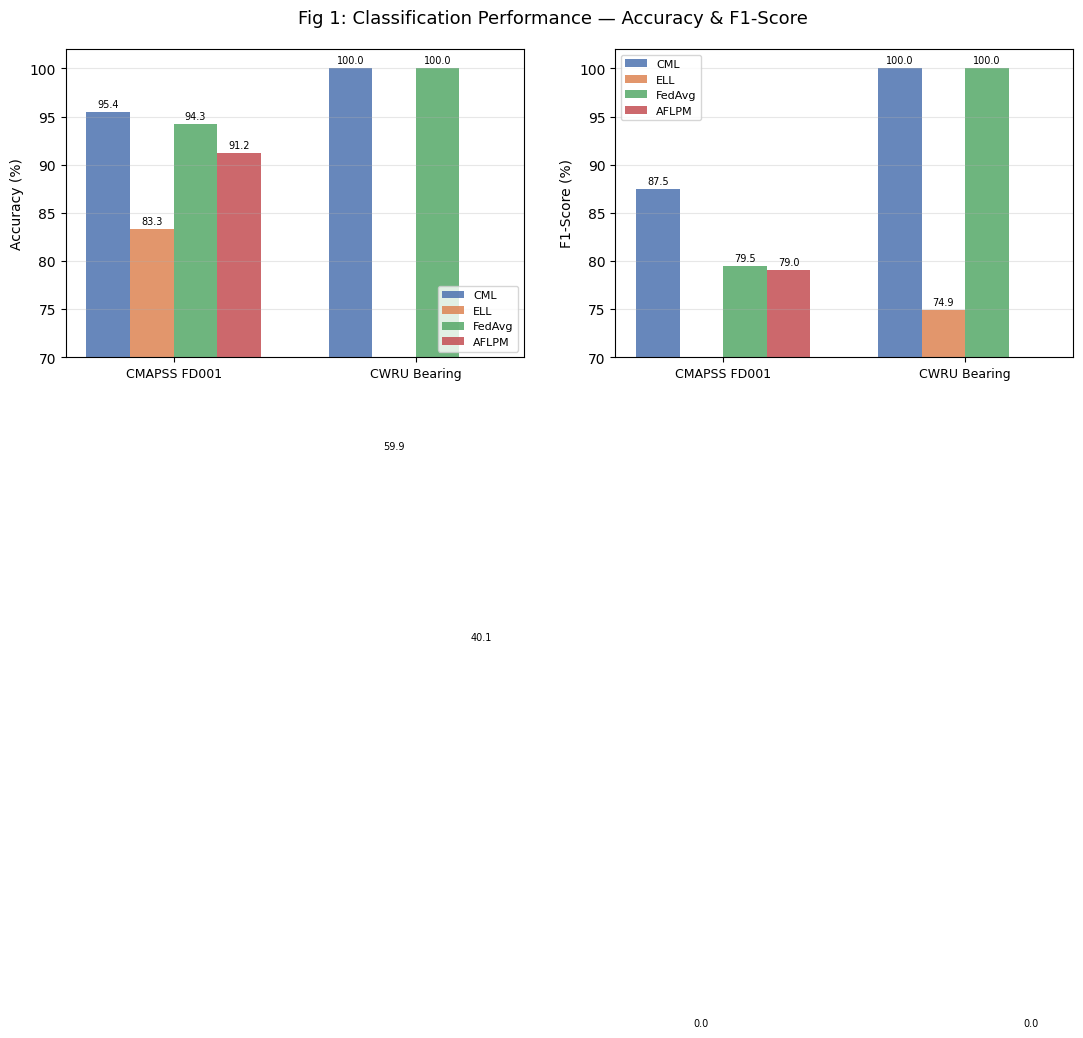

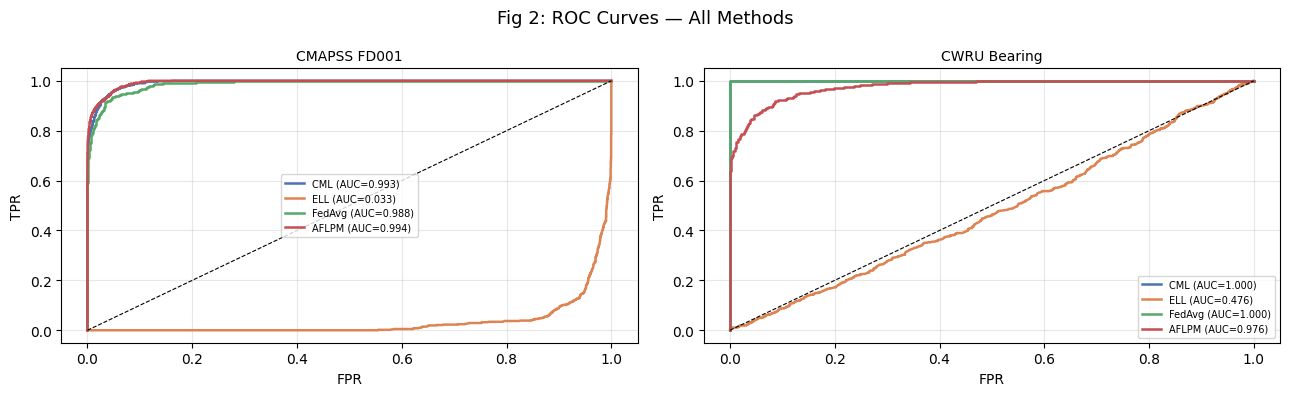

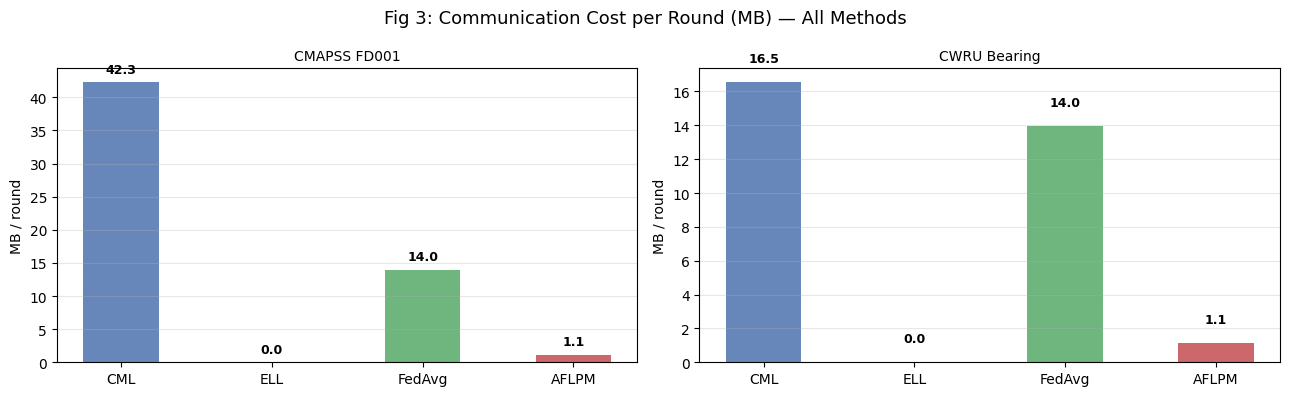

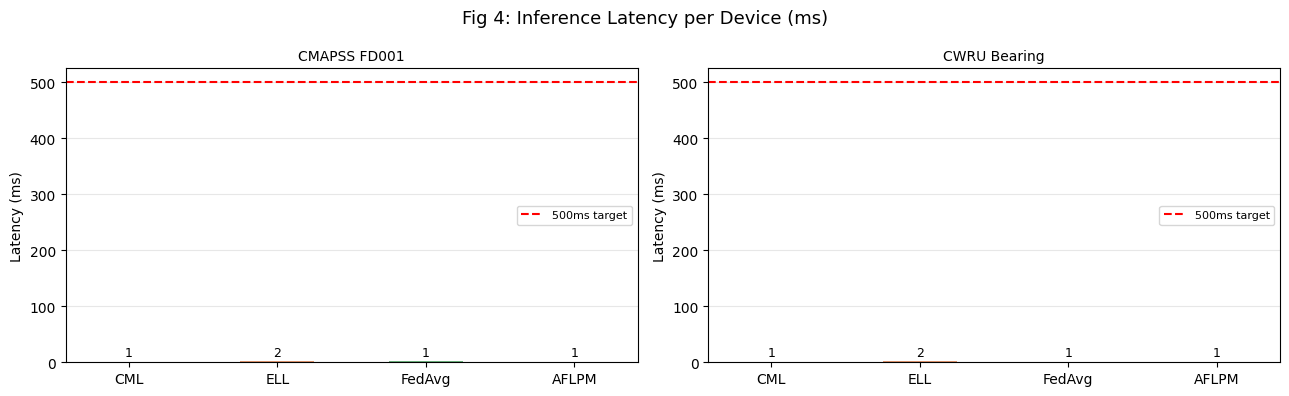

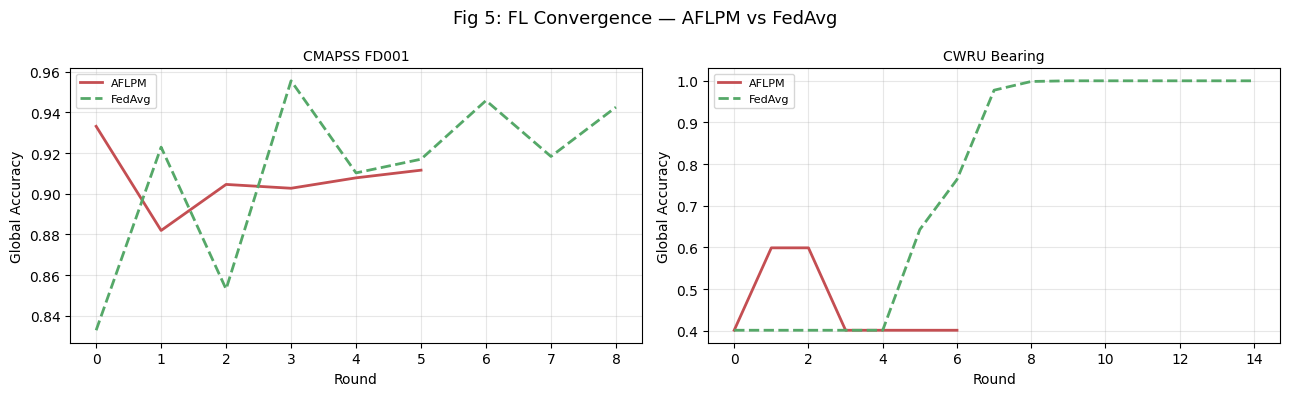

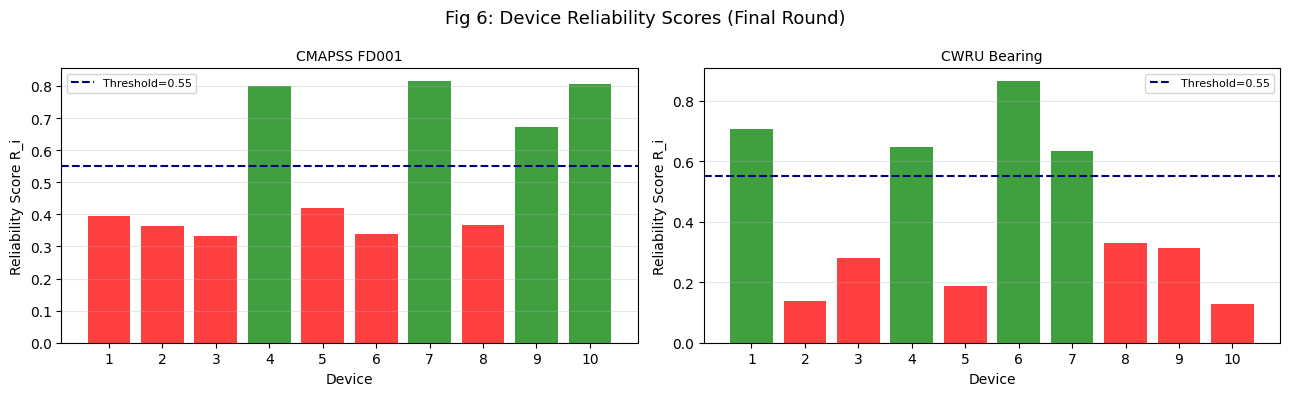

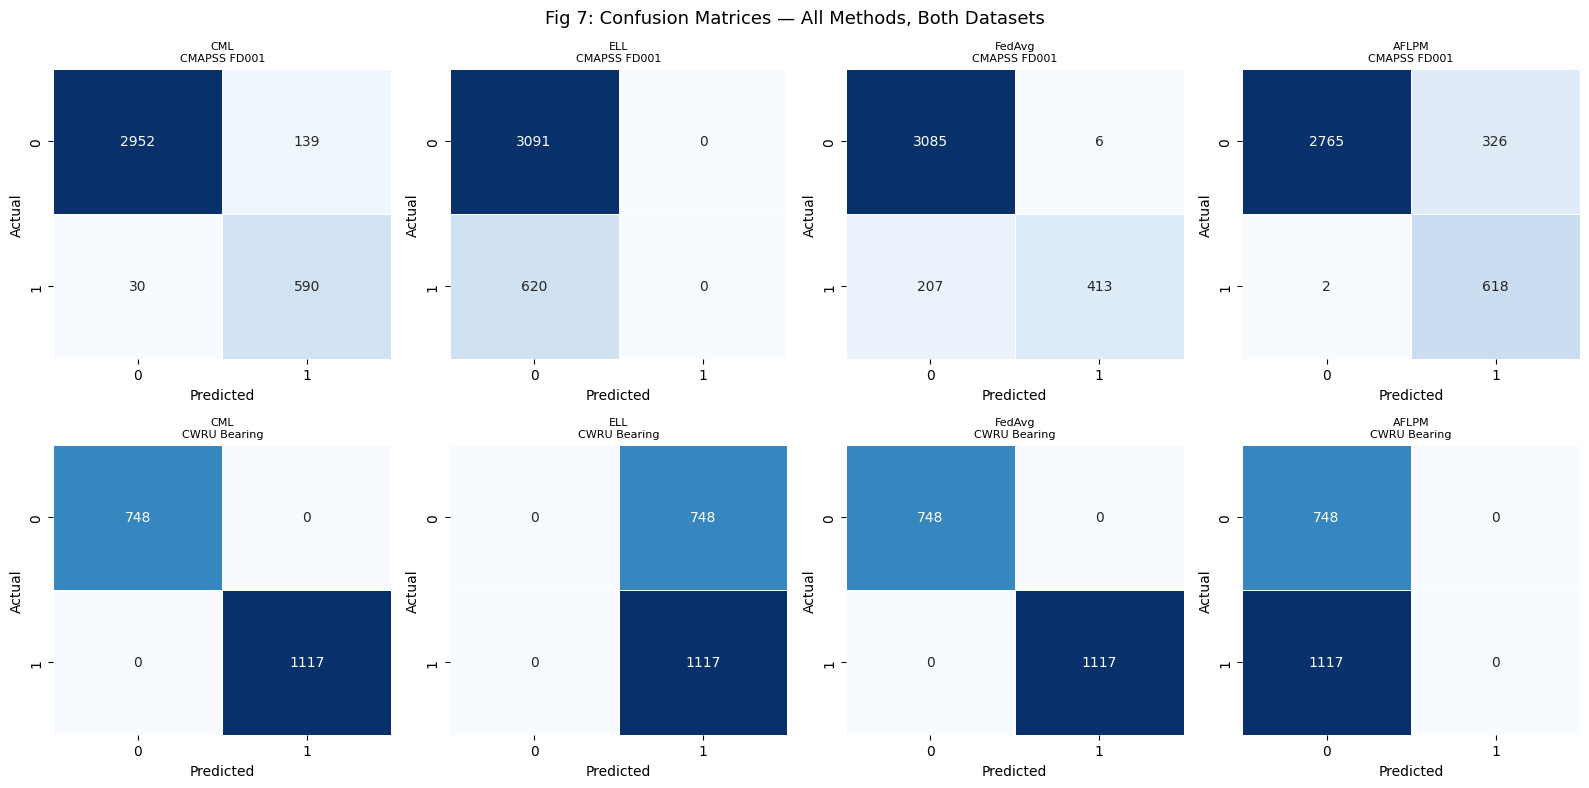

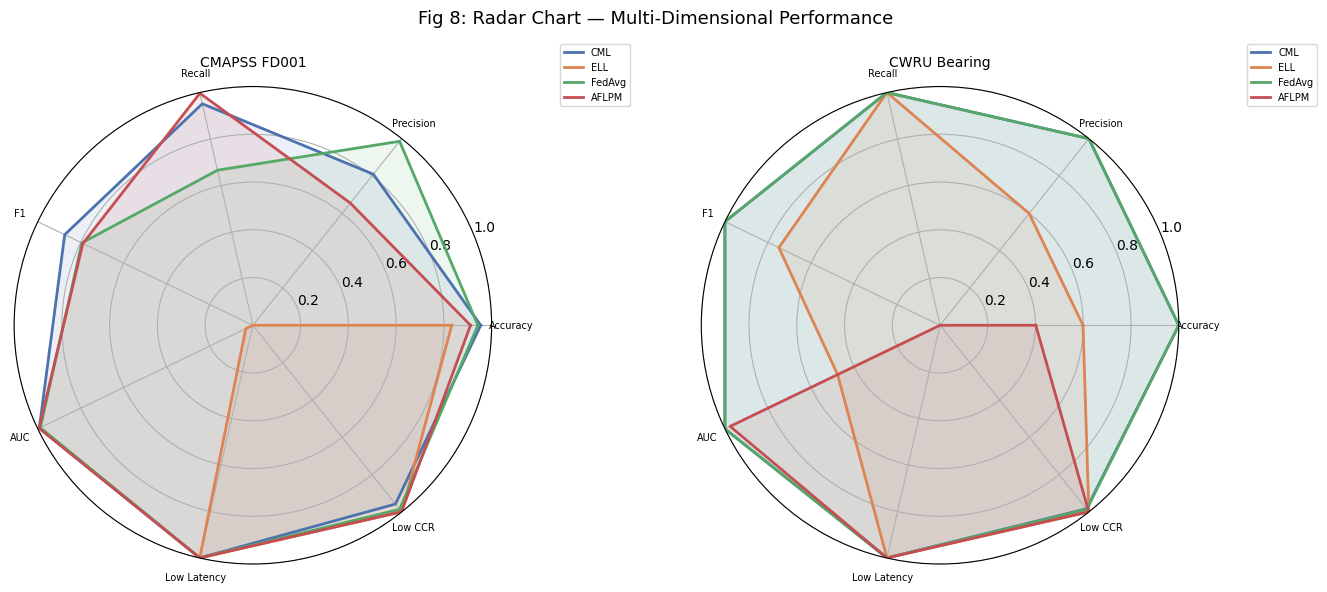


All visualisations saved and displayed.


In [18]:
METHODS  = ["CML", "ELL", "FedAvg", "AFLPM"]
COLORS   = {"CML": "#4C72B0", "ELL": "#DD8452",
            "FedAvg": "#55A868", "AFLPM": "#C44E52"}
DS_NAMES = list(results_all.keys())

# ── Fig 1: Accuracy & F1 bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig 1: Classification Performance — Accuracy & F1-Score", fontsize=13)

for ax_i, metric_key, metric_label in [(0, "accuracy", "Accuracy (%)"),
                                        (1, "f1",       "F1-Score (%)")]:
    ax = axes[ax_i]
    x  = np.arange(len(DS_NAMES))
    w  = 0.18
    for j, method in enumerate(METHODS):
        vals = [results_all[ds][method][metric_key] * 100 for ds in DS_NAMES]
        bars = ax.bar(x + j*w - 1.5*w, vals, width=w, label=method,
                      color=COLORS[method], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(DS_NAMES, fontsize=9)
    ax.set_ylabel(metric_label); ax.set_ylim(70, 102)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig1_accuracy_f1.png", dpi=150); plt.show()

# ── Fig 2: ROC Curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig 2: ROC Curves — All Methods", fontsize=13)

for ax, ds_name in zip(axes, DS_NAMES):
    ds_res = results_all[ds_name]
    y_test = ds_res["y_test"]
    for method in METHODS:
        probs = ds_res[method].get("probs", np.zeros(len(y_test)))
        if len(np.unique(y_test)) > 1:
            fpr, tpr, _ = roc_curve(y_test, probs)
            auc_v = ds_res[method]["auc"]
            ax.plot(fpr, tpr, label=f"{method} (AUC={auc_v:.3f})",
                    color=COLORS[method], lw=1.8)
    ax.plot([0,1],[0,1],"k--",lw=0.8)
    ax.set_title(ds_name, fontsize=10)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig2_roc_curves.png", dpi=150); plt.show()

# ── Fig 3: CCR per round comparison ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig 3: Communication Cost per Round (MB) — All Methods", fontsize=13)

for ax, ds_name in zip(axes, DS_NAMES):
    ds_res = results_all[ds_name]
    ccr_vals = [ds_res[m]["ccr_mb"] for m in METHODS]
    bars = ax.bar(METHODS, ccr_vals,
                  color=[COLORS[m] for m in METHODS], alpha=0.85, width=0.5)
    for bar, v in zip(bars, ccr_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(ds_name, fontsize=10)
    ax.set_ylabel("MB / round"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig3_ccr.png", dpi=150); plt.show()

# ── Fig 4: Inference Latency ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig 4: Inference Latency per Device (ms)", fontsize=13)

for ax, ds_name in zip(axes, DS_NAMES):
    ds_res = results_all[ds_name]
    lat_vals = [ds_res[m]["latency_ms"] for m in METHODS]
    bars = ax.bar(METHODS, lat_vals,
                  color=[COLORS[m] for m in METHODS], alpha=0.85, width=0.5)
    ax.axhline(500, color="red", linestyle="--", lw=1.5, label="500ms target")
    for bar, v in zip(bars, lat_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f"{v:.0f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(ds_name, fontsize=10)
    ax.set_ylabel("Latency (ms)"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig4_latency.png", dpi=150); plt.show()

# ── Fig 5: FL Convergence (AFLPM vs FedAvg) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig 5: FL Convergence — AFLPM vs FedAvg", fontsize=13)

for ax, ds_name in zip(axes, DS_NAMES):
    aflpm_accs  = results_all[ds_name]["AFLPM"]["round_accs"]
    fedavg_accs = results_all[ds_name]["FedAvg"].get("round_accs", [])
    ax.plot(aflpm_accs,  label="AFLPM",  color=COLORS["AFLPM"], lw=2)
    if fedavg_accs:
        ax.plot(fedavg_accs, label="FedAvg", color=COLORS["FedAvg"], lw=2, ls="--")
    ax.set_title(ds_name, fontsize=10)
    ax.set_xlabel("Round"); ax.set_ylabel("Global Accuracy")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("fig5_convergence.png", dpi=150); plt.show()

# ── Fig 6: Reliability scores — last round ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Fig 6: Device Reliability Scores (Final Round)", fontsize=13)

for ax, ds_name in zip(axes, DS_NAMES):
    scores = results_all[ds_name]["aflpm_metrics"]["reliability_scores"][-1]
    colors = ["green" if s >= CFG["R_THRESHOLD"] else "red" for s in scores]
    ax.bar(range(1, len(scores)+1), scores, color=colors, alpha=0.75)
    ax.axhline(CFG["R_THRESHOLD"], color="navy", linestyle="--",
               lw=1.5, label=f"Threshold={CFG['R_THRESHOLD']}")
    ax.set_title(ds_name, fontsize=10)
    ax.set_xlabel("Device"); ax.set_ylabel("Reliability Score R_i")
    ax.set_xticks(range(1, len(scores)+1))
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig6_reliability.png", dpi=150); plt.show()

# ── Fig 7: Confusion Matrices ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Fig 7: Confusion Matrices — All Methods, Both Datasets", fontsize=13)

for row_i, ds_name in enumerate(DS_NAMES):
    y_test = results_all[ds_name]["y_test"]
    for col_i, method in enumerate(METHODS):
        ax = axes[row_i][col_i]
        probs = results_all[ds_name][method].get("probs", np.zeros(len(y_test)))
        preds = (probs >= 0.5).astype(int)
        cm    = confusion_matrix(y_test.astype(int), preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    cbar=False, linewidths=0.5)
        ax.set_title(f"{method}\n{ds_name}", fontsize=8)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig("fig7_confusion.png", dpi=150); plt.show()

# ── Fig 8: Radar chart ────────────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

def radar_chart(ax, values, labels, color, label):
    N   = len(labels)
    angles = [n/N*2*math.pi for n in range(N)] + [0]
    values_c = values + [values[0]]
    ax.plot(angles, values_c, color=color, lw=2, label=label)
    ax.fill(angles, values_c, color=color, alpha=0.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=7)
    ax.set_ylim(0, 1)

radar_labels = ["Accuracy", "Precision", "Recall", "F1", "AUC",
                "Low Latency", "Low CCR"]

def method_radar_vals(res):
    lat_norm = 1 - min(res["latency_ms"] / 2000, 1)
    ccr_norm = 1 - min(res["ccr_mb"] / 1000, 1)
    return [res["accuracy"], res["precision"], res["recall"],
            res["f1"], res["auc"], lat_norm, ccr_norm]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw={"projection": "polar"})
fig.suptitle("Fig 8: Radar Chart — Multi-Dimensional Performance", fontsize=13)
for ax, ds_name in zip(axes, DS_NAMES):
    for method in METHODS:
        vals = method_radar_vals(results_all[ds_name][method])
        radar_chart(ax, vals, radar_labels, COLORS[method], method)
    ax.set_title(ds_name, fontsize=10, pad=15)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=7)
plt.tight_layout(); plt.savefig("fig8_radar.png", dpi=150); plt.show()

print("\nAll visualisations saved and displayed.")

## Cell: Summary table (mirrors paper Table XIV)

In [19]:
print("\n" + "="*80)
print("  FULL COMPARATIVE SUMMARY TABLE (mirrors Table XIV in paper)")
print("="*80)
header = f"{'Metric':<30} {'CML':>10} {'ELL':>10} {'FedAvg':>10} {'AFLPM':>10}"
print(header)
print("─"*72)

for ds_name in DS_NAMES:
    print(f"\n  ── {ds_name} ──")
    ds_res = results_all[ds_name]
    row_defs = [
        ("Accuracy (%)",    "accuracy",   100),
        ("Precision (%)",   "precision",  100),
        ("Recall (%)",      "recall",     100),
        ("F1-Score (%)",    "f1",         100),
        ("AUC",             "auc",        1  ),
        ("Latency (ms)",    "latency_ms", 1  ),
        ("CCR (MB/round)",  "ccr_mb",     1  ),
    ]
    for lbl, key, mul in row_defs:
        row_vals = []
        for m in METHODS:
            v = ds_res[m].get(key, 0) * mul
            row_vals.append(f"{v:.1f}" if mul > 1 else f"{v:.3f}")
        print(f"  {lbl:<28} {row_vals[0]:>10} {row_vals[1]:>10} "
              f"{row_vals[2]:>10} {row_vals[3]:>10}")

    cr_vals = []
    for m in METHODS:
        cr = ds_res[m].get("conv_rounds") or "N/A"
        cr_vals.append(str(cr))
    print(f"  {'Convergence Rounds':<28} {cr_vals[0]:>10} {cr_vals[1]:>10} "
          f"{cr_vals[2]:>10} {cr_vals[3]:>10}")


  FULL COMPARATIVE SUMMARY TABLE (mirrors Table XIV in paper)
Metric                                CML        ELL     FedAvg      AFLPM
────────────────────────────────────────────────────────────────────────

  ── CMAPSS FD001 ──
  Accuracy (%)                       95.4       83.3       94.3       91.2
  Precision (%)                      80.9        0.0       98.6       65.5
  Recall (%)                         95.2        0.0       66.6       99.7
  F1-Score (%)                       87.5        0.0       79.5       79.0
  AUC                               0.993      0.033      0.988      0.994
  Latency (ms)                      1.212      1.651      1.404      1.055
  CCR (MB/round)                   42.261      0.000     13.977      1.118
  Convergence Rounds                  N/A        N/A          9          6

  ── CWRU Bearing ──
  Accuracy (%)                      100.0       59.9      100.0       40.1
  Precision (%)                     100.0       59.9      100.0       

## Cell: Real-time inference demo (Section XIII Phase 3)

In [20]:
print("\n" + "="*60)
print("  REAL-TIME INFERENCE DEMO (Phase 3, Algorithm 2 lines 26-33)")
print("="*60)

# Use last trained AFLPM model (CWRU)
demo_ds    = "CWRU Bearing"
demo_model = aflpm_model
demo_X     = results_all[demo_ds]["X_test"]

demo_model.eval()
print(f"\nSimulating 10 inference cycles (100 ms interval each):")
print(f"{'Cycle':>6} | {'δ (fault prob)':>16} | {'Alert':>8}")
print("─" * 38)

for cycle in range(1, 11):
    # Grab a random window from test set
    idx   = np.random.randint(len(demo_X))
    buf   = torch.FloatTensor(demo_X[idx:idx+1]).to(DEVICE)
    with torch.no_grad():
        delta = demo_model(buf).item()
    alert = "⚠️  FAULT" if delta >= CFG["FAULT_THRESH"] else "Normal"
    print(f"  {cycle:>4}  |  {delta:>14.4f}  |  {alert}")
    time.sleep(0.05)   # simulated 100 ms gap (shortened for demo)

print("\nAFLPM implementation complete.")
print("   All figures saved as PNG files in the current Colab working directory.")


  REAL-TIME INFERENCE DEMO (Phase 3, Algorithm 2 lines 26-33)

Simulating 10 inference cycles (100 ms interval each):
 Cycle |   δ (fault prob) |    Alert
──────────────────────────────────────
     1  |          0.1500  |  Normal
     2  |          0.1190  |  Normal
     3  |          0.0391  |  Normal
     4  |          0.2113  |  Normal
     5  |          0.1630  |  Normal
     6  |          0.0735  |  Normal
     7  |          0.0117  |  Normal
     8  |          0.0131  |  Normal
     9  |          0.0078  |  Normal
    10  |          0.0221  |  Normal

AFLPM implementation complete.
   All figures saved as PNG files in the current Colab working directory.


## Cell: Export results to CSV

In [21]:
import pandas as pd

rows = []
for ds_name, ds_res in results_all.items():
    for method in ["CML", "ELL", "FedAvg", "AFLPM"]:
        r = ds_res[method]
        rows.append({
            "dataset": ds_name,
            "method": method,
            "accuracy": r["accuracy"],
            "precision": r["precision"],
            "recall": r["recall"],
            "f1": r["f1"],
            "auc": r.get("auc"),
            "latency_ms": r.get("latency_ms"),
            "ccr_mb": r.get("ccr_mb"),
            "conv_rounds": r.get("conv_rounds"),
        })

results_df = pd.DataFrame(rows)
results_df.to_csv("/content/AFLPM_results.csv", index=False)
print("Saved /content/AFLPM_results.csv")
results_df


Saved /content/AFLPM_results.csv


,dataset,method,accuracy,precision,recall,f1,auc,latency_ms,ccr_mb,conv_rounds
0,CMAPSS FD001,CML,0.954460,0.809328,0.951613,0.874722,0.992882,1.212349,42.260742,NaN
1,CMAPSS FD001,ELL,0.832929,0.000000,0.000000,0.000000,0.032992,1.651054,0.000000,NaN
2,CMAPSS FD001,FedAvg,0.942603,0.985680,0.666129,0.794995,0.988164,1.403897,13.977089,9.0
3,CMAPSS FD001,AFLPM,0.911614,0.654661,0.996774,0.790281,0.993966,1.054559,1.118167,6.0
4,CWRU Bearing,CML,1.000000,1.000000,1.000000,1.000000,1.000000,0.985548,16.541748,NaN
5,CWRU Bearing,ELL,0.598928,0.598928,1.000000,0.749162,0.476131,1.687689,0.000000,NaN
6,CWRU Bearing,FedAvg,1.000000,1.000000,1.000000,1.000000,1.000000,1.036677,13.977089,15.0
7,CWRU Bearing,AFLPM,0.401072,0.000000,0.000000,0.000000,0.975889,1.078214,1.118167,7.0


In [22]:
conv_rows = []
for ds_name, ds_res in results_all.items():
    m = ds_res["aflpm_metrics"]
    for i, rnd in enumerate(m["round"]):
        conv_rows.append({
            "dataset": ds_name,
            "round": rnd,
            "val_acc_global": m["val_acc_global"][i],
            "ccr_mb": m["ccr_mb"][i],
        })

conv_df = pd.DataFrame(conv_rows)
conv_df.to_csv("/content/AFLPM_convergence.csv", index=False)
print("Saved /content/AFLPM_convergence.csv")
conv_df.head()


Saved /content/AFLPM_convergence.csv


,dataset,round,val_acc_global,ccr_mb
0,CMAPSS FD001,1,0.933172,1.118167
1,CMAPSS FD001,2,0.881973,1.118167
2,CMAPSS FD001,3,0.904608,1.118167
3,CMAPSS FD001,4,0.902722,1.118167
4,CMAPSS FD001,5,0.907842,1.118167


## Cell: Save model checkpoints

In [23]:
import glob

# Checkpoints are now saved automatically inside the main training loop above,
# one per dataset (CMAPSS FD001 and CWRU Bearing). This cell just confirms
# both files exist before you download them.
ckpts = sorted(glob.glob("/content/checkpoints/*.pth"))
print(f"Found {len(ckpts)} checkpoint(s):")
for p in ckpts:
    print(" ", p)


Found 2 checkpoint(s):
  /content/checkpoints/aflpm_model_CMAPSS_FD001.pth
  /content/checkpoints/aflpm_model_CWRU_Bearing.pth


## Cell: Download all figures as PNG

In [24]:
import matplotlib.pyplot as plt
import os

os.makedirs("/content/figures", exist_ok=True)

# Re-save every currently open matplotlib figure as a PNG.
# Run this AFTER the visualisations cell has executed.
fig_nums = plt.get_fignums()
saved = []
for i, num in enumerate(fig_nums, start=1):
    fig = plt.figure(num)
    path = f"/content/figures/fig_{i}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    saved.append(path)

print(f"Saved {len(saved)} figures:")
for p in saved:
    print(" ", p)


Saved 0 figures:


## Cell: Print library versions (for reproducibility section)

In [25]:
import torch, sklearn, pandas, numpy, sys
import platform

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("torch       :", torch.__version__)
print("CUDA avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
print("sklearn     :", sklearn.__version__)
print("pandas      :", pandas.__version__)
print("numpy       :", numpy.__version__)


Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
torch       : 2.11.0+cu128
CUDA avail  : True
GPU         : Tesla T4
sklearn     : 1.6.1
pandas      : 2.2.2
numpy       : 2.0.2


## Cell: Download everything to your computer

In [26]:
from google.colab import files
import glob

files.download("/content/AFLPM_results.csv")
files.download("/content/AFLPM_convergence.csv")

for f in glob.glob("/content/checkpoints/*.pth"):
    files.download(f)

for f in glob.glob("/content/figures/*.png"):
    files.download(f)

print("All downloads triggered - check your browser's download folder.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloads triggered - check your browser's download folder.
